# Single-cell TCR + transcriptome — the immune-repertoire pipeline

This is the **flagship `ov.airr` single-cell tutorial**. It walks the complete
workflow for a paired single-cell **TCR-seq + gene-expression** experiment on a
real published dataset, and — as importantly — explains **why** each step is
done the way it is.

## Why paired single-cell immune-repertoire data

A T cell carries two identities at once. Its **transcriptome** says what *state*
it is in — naive, effector, exhausted, regulatory. Its **T-cell receptor (TCR)**
says what *clone* it belongs to: the receptor is assembled once by V(D)J
recombination and then copied unchanged into every daughter cell, so all the
descendants of one activated T cell share an identical receptor. The receptor is
a **natural lineage barcode**.

10x 5'-end single-cell sequencing reads *both* from the same cell:

- a **gene-expression (GEX)** library — the transcriptome, in `adata.X`;
- a **V(D)J (TCR)** library — the rearranged receptor contigs.

Crossing the two answers the question bulk data cannot: *which transcriptional
states are clonally expanded?* A clone that has been driven to proliferate by
antigen will appear as many cells sharing one receptor — and if those cells also
share a transcriptional state, that state is the one responding to antigen.

## The dataset — Wu et al., *Nature* 2020

We use the tumour-infiltrating T-cell atlas of **Wu et al. 2020**
(*Nature* 580:257, PMID 32103181). The study profiled T cells from **14 cancer
patients** (lung, kidney, colorectal, endometrial) with 10x 5' scRNA-seq +
paired scTCR-seq, sampling three compartments per patient:

- **Tumor** — the tumour itself;
- **NAT** — normal adjacent tissue;
- **Blood** — peripheral blood.

Its central finding: tumour-reactive, clonally expanded T cells are concentrated
in **exhausted / effector CD8** states inside the tumour — and clonotype
sharing reveals movement of clones between blood, normal tissue and tumour.
This tutorial reproduces the backbone of that analysis with `ov.airr`.

## The pipeline

```
load → bridge obsm['airr'] → chain QC → clonotype definition
     → clonal expansion → clonotype network → diversity & overlap
     → V(D)J usage → repertoire x transcriptome
```

Every stage is one `ov.airr` call — the same registered, dispatch-based design
as `ov.protein` and `ov.es`.

## 0. Setup

`ov.airr` is the immune-repertoire suite of omicverse. Its single-cell side is
**AnnData-native**: the gene-expression matrix stays in `adata.X` and the
per-cell receptor data lives in `adata.obs`, so TCR analysis composes directly
with the rest of the omicverse single-cell stack via `ov.*` — no separate
object and no external single-cell library needed.

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the data

`ov.datasets.airr_singlecell()` fetches the Wu 2020 atlas as a single AnnData.
In a real project you would instead parse your own 10x Cell Ranger V(D)J output
with the matching `ov.airr` reader:

| Upstream output | Reader |
|---|---|
| 10x `filtered_contig_annotations.csv` | `ov.airr.read_10x_vdj(...)` |
| 10x `airr_rearrangement.tsv` | `ov.airr.read_10x_vdj(...)` |
| AIRR-format rearrangement TSV | `ov.airr.read_airr(...)` |
| arbitrary per-contig table | `ov.airr.read_tracer(...)` |

All readers return the same per-cell AIRR layout, so the rest of this pipeline
is identical regardless of upstream software.

In [2]:
adata = ov.datasets.airr_singlecell()
print(f"matrix: {adata.n_obs} cells x {adata.n_vars} genes")
print(f"raw counts in .X — max value {adata.X.max():.0f}")
print(f"obs columns : {list(adata.obs.columns)}")
print(f"obsm keys   : {list(adata.obsm.keys())}")

🔍 Downloading data to ./data/wu2020_sctcr.h5ad


Downloading: |                                                                                                       | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                               | 0.00/13.3M [00:00<?, ?B/s]

Downloading:  75%|█████████████████████████████████████████████████████████████████▍                     | 10.0M/13.3M [00:00<00:00, 100MB/s]

Downloading: 100%|█████████████████████████████████████████████████████████████████████████████████████▉| 13.3M/13.3M [00:00<00:00, 32.4MB/s]

✅ Download completed


matrix: 5001 cells x 13968 genes
raw counts in .X — max value 9493
obs columns : ['patient', 'sample', 'source', 'cluster_orig', 'cell_type', 'clonotype_orig', 'high_confidence', 'is_cell']
obsm keys   : ['X_umap_orig', 'airr']


The object carries **5001 T cells x 13968 genes**. Two pieces of metadata
matter for everything below:

- **`obsm['airr']`** — the per-cell TCR contigs, stored as a *ragged*
  (variable-length) awkward array: each cell has its own list of receptor
  chains. This is the scirpy on-disk layout; we bridge it to the `ov.airr`
  schema in the next step.
- **`obsm['X_umap_orig']`** — the transcriptome UMAP published with the paper,
  so we can place every cell in its GEX state without recomputing the
  embedding.

`.obs` carries the study design — `patient`, `sample`, `source`
(Tumor / NAT / Blood) — and the authors' transcriptomic annotation in
`cell_type` / `cluster_orig` (e.g. `8.1-Teff`, `8.3a-Trm`, `4.3-TCF7`).

In [3]:
for c in ["source", "patient"]:
    print(f"--- {c} ---")
    print(adata.obs[c].value_counts())

--- source ---
source
Tumor    2594
NAT      2065
Blood     342
Name: count, dtype: int64
--- patient ---
patient
Lung2     707
Lung3     624
Lung6     619
Lung1     541
Endo1     520
Lung4     455
Renal2    357
Lung5     251
Endo2     203
Endo3     198
Renal1    196
Colon1    154
Renal3    151
Colon2     25
Name: count, dtype: int64


**2594 tumour, 2065 normal-adjacent, 342 blood** T cells, drawn from
**14 patients**. That three-compartment, multi-patient design is what lets us
ask later whether the tumour repertoire is more clonally focused than blood,
and whether clones are shared across tissues.

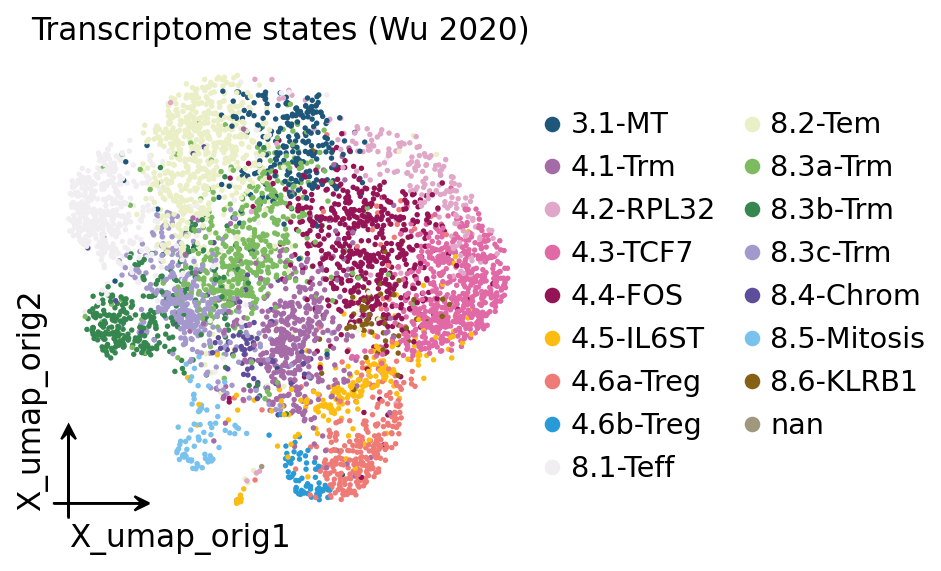

In [4]:
ov.pl.embedding(adata, basis="X_umap_orig", color="cell_type",
                frameon="small", title="Transcriptome states (Wu 2020)",
                show=False)
plt.show()

This is the **transcriptome** view — every dot a T cell, coloured by the
authors' state annotation. The `4.x` labels are CD4 states (naive-like
`4.3-TCF7`, regulatory `4.6-Treg`, tissue-resident `4.1-Trm`); the `8.x` labels
are CD8 states (effector `8.1-Teff`, tissue-resident memory `8.3a/b/c-Trm`,
effector-memory `8.2-Tem`). The whole tutorial asks: **which of these states is
clonally expanded?** — but to answer it we first need the TCR.

## 2. Bridge the receptor data into the `ov.airr` schema

The TCR contigs sit in `obsm['airr']` as a ragged array — convenient for
storage, awkward for analysis. `ov.airr.from_airr_array` flattens those contigs
and collapses them into a fixed per-cell schema in `adata.obs`:

- **`VJ_1` / `VJ_2`** — the VJ-arm chains (TRA, the TCR **alpha** chain) —
  primary and secondary;
- **`VDJ_1` / `VDJ_2`** — the VDJ-arm chains (TRB, the TCR **beta** chain).

Within each arm the chains are ranked by UMI support, so `VJ_1` / `VDJ_1` are
the dominant, most-expressed receptor. The gene-expression matrix and all the
original `obs` metadata are preserved untouched.

In [5]:
adata = ov.airr.from_airr_array(adata)
new_cols = [c for c in adata.obs.columns if c.startswith(("VJ_", "VDJ_"))]
print(f"per-cell AIRR columns added : {len(new_cols)}")
print(f"receptor type per cell:")
print(adata.obs["receptor_type"].value_counts())

per-cell AIRR columns added : 36
receptor type per cell:
receptor_type
TCR          4691
ambiguous     279
no IR          27
BCR             4
Name: count, dtype: int64


Almost every cell carries a **TCR**, as expected for a sorted T-cell
study. A handful are flagged `ambiguous` (contigs from both TCR and BCR loci —
usually ambient contamination) and a few have `no IR` (no receptor recovered at
all). We have not filtered anything yet; we just classified.

## 3. Chain QC — is the receptor usable?

Not every receptor a droplet reports is biologically plausible. A real T cell
has **one productive alpha + one productive beta** chain. Cell Ranger output
deviates from that ideal for two reasons: doublets (two cells in one droplet →
*too many* chains) and dropout (one chain not captured → *too few*).
`ov.airr.chain_qc` classifies every cell by its chain configuration:

- **`single pair`** — one VJ + one VDJ chain. The clean, analysable case.
- **`orphan VDJ` / `orphan VJ`** — only the beta, or only the alpha, recovered.
  Still usable for clonotype calling (one chain is informative), just less
  specific.
- **`multichain`** — more than two chains in one arm. The hallmark of a
  **doublet**; these cells must be excluded — a spurious receptor would create
  a fake clonotype.
- **`no IR`** — no receptor at all.

In [6]:
ov.airr.chain_qc(adata)
print(adata.obs["chain_pairing"].value_counts())
print()
print("receptor subtype:")
print(adata.obs["receptor_subtype"].value_counts().head(3))

chain_pairing
single pair    2593
orphan VDJ     1330
multichain      483
no IR           330
orphan VJ       265
Name: count, dtype: int64

receptor subtype:
receptor_subtype
TRA+TRB      4693
ambiguous     277
no IR          27
Name: count, dtype: int64


The receptor subtype is overwhelmingly **TRA+TRB** — confirming this is a
clean αβ T-cell dataset.

We now build the analysis set: keep cells with a `single pair` or an `orphan`
chain (all carry a usable receptor for clonotype calling) and drop `multichain`
doublets and `no IR` cells. This is the central QC decision — every clonotype
downstream is only as trustworthy as the receptors that define it.

In [7]:
usable = ["single pair", "orphan VJ", "orphan VDJ"]
tcr = adata[adata.obs["chain_pairing"].isin(usable)].copy()
n_drop = adata.n_obs - tcr.n_obs
print(f"cells with a usable TCR : {tcr.n_obs} / {adata.n_obs}")
print(f"dropped (multichain / no IR): {n_drop}")

cells with a usable TCR : 4188 / 5001
dropped (multichain / no IR): 813


**4188 cells** carry a usable TCR and form the repertoire we analyse from
here on. The dropped ~800 cells are mostly multichain doublets — excluding them
*before* clonotype definition is what keeps the clone calls clean.

## 4. Clonotype definition

A **clonotype** is a set of cells that descend from one ancestral T cell — they
share an identical receptor. `ov.airr` offers two definitions, and the
difference matters.

**`define_clonotypes`** — *exact identity*. Cells whose primary alpha + beta
CDR3 sequences are **identical** form one clonotype. This is the strict,
conservative definition: it counts true clonal descendants. The CDR3 is the
hypervariable loop that contacts antigen; identical CDR3s on both chains is
overwhelming evidence of a shared ancestor.

In [8]:
ov.airr.define_clonotypes(tcr)
n_clono = tcr.uns["clonotype"]["n_clonotypes"]
print(f"exact clonotypes : {n_clono}")
print(f"largest clone    : {int(tcr.obs['clone_id_size'].max())} cells")
print(f"cells in a clone of size >= 2: "
      f"{int((tcr.obs['clone_id_size'] >= 2).sum())}")

exact clonotypes : 3348
largest clone    : 27 cells
cells in a clone of size >= 2: 1102


**`define_clonotype_clusters`** — *distance-based*. Cells whose CDR3
sequences are merely *similar* (within a small edit distance) are merged into a
clonotype **cluster** via connected components. This is the looser definition:
it captures **convergent** receptors — independent T cells that recombined
near-identical receptors because they recognise the same antigen — and absorbs
small sequencing errors. We allow a Hamming distance of 1 (one mismatched
residue).

In [9]:
ov.airr.define_clonotype_clusters(tcr, metric="hamming", cutoff=1)
n_clust = tcr.uns["clonotype_clusters"]["n_clusters"]
print(f"exact clonotypes        : {n_clono}")
print(f"distance-based clusters : {n_clust}")

exact clonotypes        : 3348
distance-based clusters : 3331


The cluster count is slightly **lower** than the exact count: allowing one
mismatch merges a few near-identical receptors that strict identity kept apart.
The gap is small here because TCRs (unlike hypermutating BCRs) do not
somatically mutate — so for the rest of this tutorial we use the **exact**
`clone_id`, the conservative choice for TCR data.

## 5. Clonal expansion

`define_clonotypes` gives every cell a clone *size*; `clonal_expansion` turns
that continuous size into an interpretable category — `1 (single)`, `2`, `3`,
`>= 4` — so we can ask what fraction of the repertoire is expanded.

In [10]:
ov.airr.clonal_expansion(tcr)
exp = tcr.obs["clonal_expansion"].value_counts()
frac_exp = 100.0 * (tcr.obs["clonal_expansion"] != "1 (single)").mean()
print(exp)
print(f"\ncells in an expanded (>=2) clone: {frac_exp:.1f}%")

clonal_expansion
1 (single)    3010
>= 4           531
2              424
3              147
Name: count, dtype: int64

cells in an expanded (>=2) clone: 28.1%


Roughly a quarter of the cells sit in an **expanded** clone (size ≥ 2),
and a substantial group falls in the `>= 4` bucket — large clones that have
proliferated extensively. The other three-quarters are **singletons**: clones
seen exactly once. A repertoire that is part highly-expanded, part vast
singleton tail is the classic signature of an **antigen-experienced** T-cell
population — a few clones driven to expand against specific antigens, on a
background of unexpanded diversity.

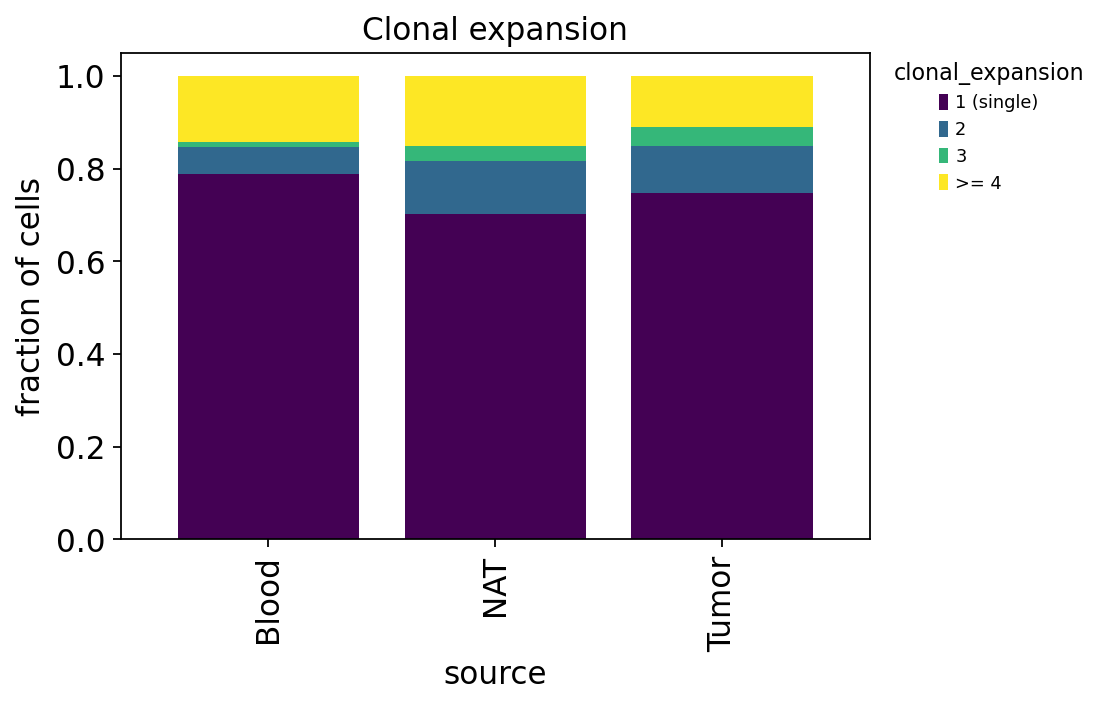

In [11]:
ov.airr.clonal_expansion_plot(tcr, groupby="source")
plt.show()

Split by tissue, the expanded fraction is **highest in the tumour** and
lowest in blood — the first hint of the paper's story: the tumour
microenvironment locally drives clonal proliferation. We quantify that
rigorously with diversity metrics in section 7.

## 6. Clonotype network

The clonotype network is a graph view of the repertoire: every cell is a node,
and an edge links two cells whose receptors are identical (or, with a cutoff,
similar). Connected components are clonotypes; large dense blobs are expanded
clones, isolated dots are singletons. `clonotype_network` computes a 2-D layout
and stores it in `obsm['X_clonotype_network']`.

We set `min_cells=2` to **hide singletons** — with thousands of unique
receptors they would swamp the plot — and focus the layout on the expanded
clones that carry the biological signal.

In [12]:
ov.airr.clonotype_network(tcr, min_cells=2)
n_comp = tcr.uns["clonotype_network"]["n_components"]
print(f"expanded clonotypes drawn (size >= 2): {n_comp}")

expanded clonotypes drawn (size >= 2): 338


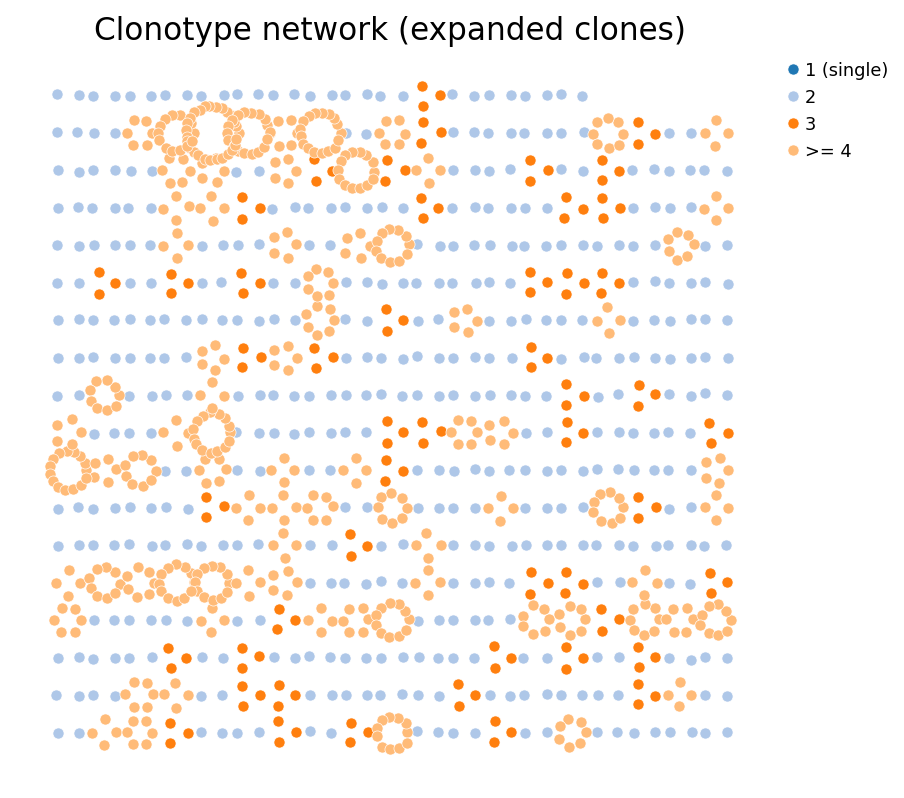

In [13]:
ov.airr.clonotype_network_plot(tcr, color="clonal_expansion",
                               title="Clonotype network (expanded clones)")
plt.show()

Each ring is one expanded clonotype; ring **size scales with clone
size**. The big rings — coloured by the `>= 4` category — are the dominant
clones that have proliferated most. This is the repertoire's clonal skeleton:
a few large families standing out from many small ones.

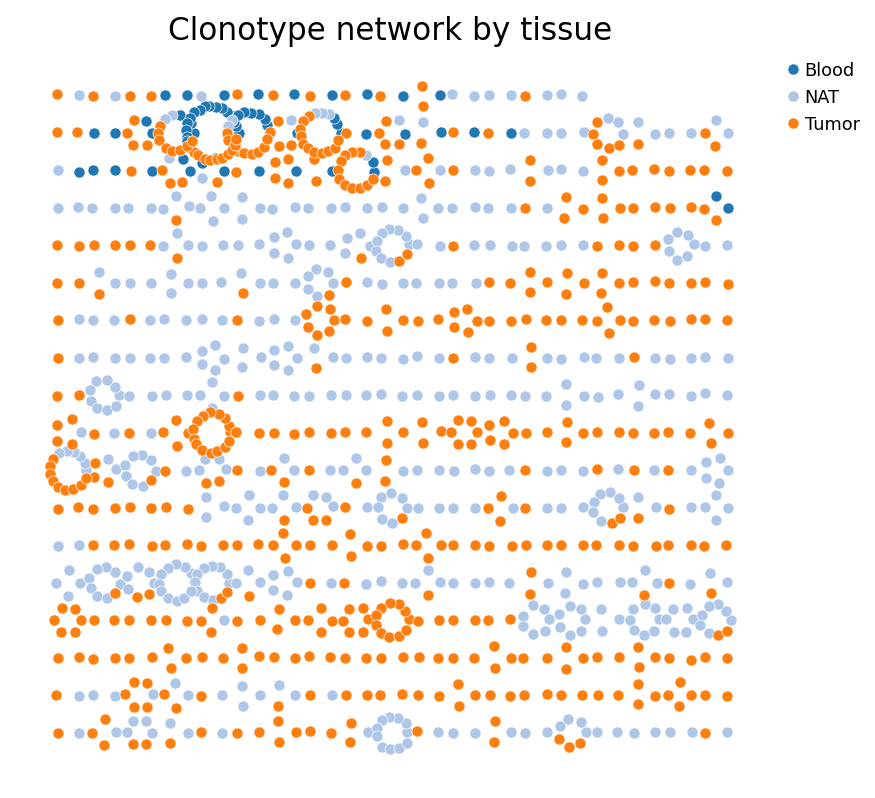

In [14]:
ov.airr.clonotype_network_plot(tcr, color="source",
                               title="Clonotype network by tissue")
plt.show()

Re-colouring the *same* layout by tissue is revealing: many rings mix
**Tumor and NAT** (and occasionally Blood) cells. A single clonotype spanning
two compartments means **one clonal family is present in both** — direct
evidence that T-cell clones traffic between normal tissue and tumour, exactly
the clonal-sharing phenomenon Wu 2020 reported.

## 7. Repertoire diversity and overlap

### Alpha diversity — how clonally focused is each compartment?

A repertoire dominated by a few big clones is *less diverse* than one of equal
size made of many small clones. `alpha_diversity` quantifies this from the
clone-size distribution. We use **normalized Shannon entropy** (1 = perfectly
even, every clone unique; lower = a few clones dominate), computed per tissue.

In [15]:
div = ov.airr.alpha_diversity(tcr, groupby="source",
                              metric="normalized_shannon")
print(div)

       n_cells  n_clonotypes  normalized_shannon
group                                           
Blood      307           272            0.975210
NAT       1678          1378            0.980015
Tumor     2127          1818            0.984513


All three values are high — most clones are still singletons everywhere —
but the **ordering** is the biology: diversity is **lowest in the tumour** and
highest in blood. The tumour repertoire is the most *clonally focused*: a subset
of clones has expanded there at the expense of evenness, which is what
antigen-driven proliferation inside the tumour produces. Blood, a transit
compartment not under local antigen pressure, stays the most even.

In [16]:
gini = ov.airr.alpha_diversity(tcr, groupby="source", metric="gini_simpson")
d50 = ov.airr.alpha_diversity(tcr, groupby="source", metric="d50")
summary = pd.DataFrame({
    "n_cells": div["n_cells"], "n_clonotypes": div["n_clonotypes"],
    "norm_shannon": div["normalized_shannon"].round(3),
    "gini_simpson": gini["gini_simpson"].round(3),
    "d50": d50["d50"],
})
summary

,n_cells,n_clonotypes,norm_shannon,gini_simpson,d50
group,,,,,
Blood,307,272,0.975,0.993,119
NAT,1678,1378,0.980,0.999,539
Tumor,2127,1818,0.985,0.999,755


Three diversity metrics agree. **D50** — the number of top clones needed
to cover half the cells — is the most intuitive: a smaller D50 means a few
clones carry the repertoire. Reading the table by tissue confirms the tumour is
the most clonally constricted compartment.

### Repertoire overlap — are clonotypes shared between patients?

`repertoire_overlap` builds a pairwise matrix of how many clonotypes two groups
share. Computed across the 14 patients with the **Jaccard index**, it tests
whether clonotypes are *private* (each patient's TCRs unique to them) or
*public* (shared).

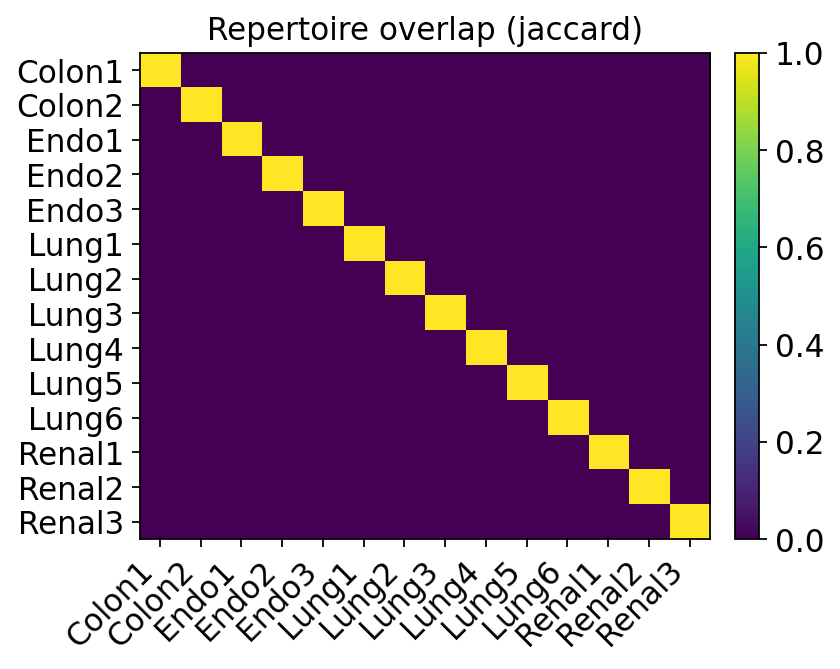

In [17]:
ov.airr.repertoire_overlap_plot(tcr, groupby="patient", metric="jaccard")
plt.show()

The heatmap is **near-zero off the diagonal**: almost no clonotype is
shared between patients. This is expected and reassuring — an exact-CDR3
clonotype is essentially patient-private, because V(D)J recombination plus
each individual's HLA make the odds of two people independently producing the
identical receptor vanishingly small. It also validates the clonotype
definition: if unrelated patients *did* share many clones, we would suspect a
barcode or demultiplexing artefact. Clonal expansion here is a **within-patient,
within-tumour** process.

## 8. V(D)J gene usage

Before recombination, each TCR chain picks one **V**, (one **D**,) and one **J**
gene segment from the germline. The frequency with which each segment is used —
the **gene-usage profile** — is a coarse fingerprint of a repertoire; strong
skewing can flag a biased or antigen-selected response. `vdj_usage` tabulates
segment frequencies, here for the **TRBV** (beta-chain V) genes, split by
tissue.

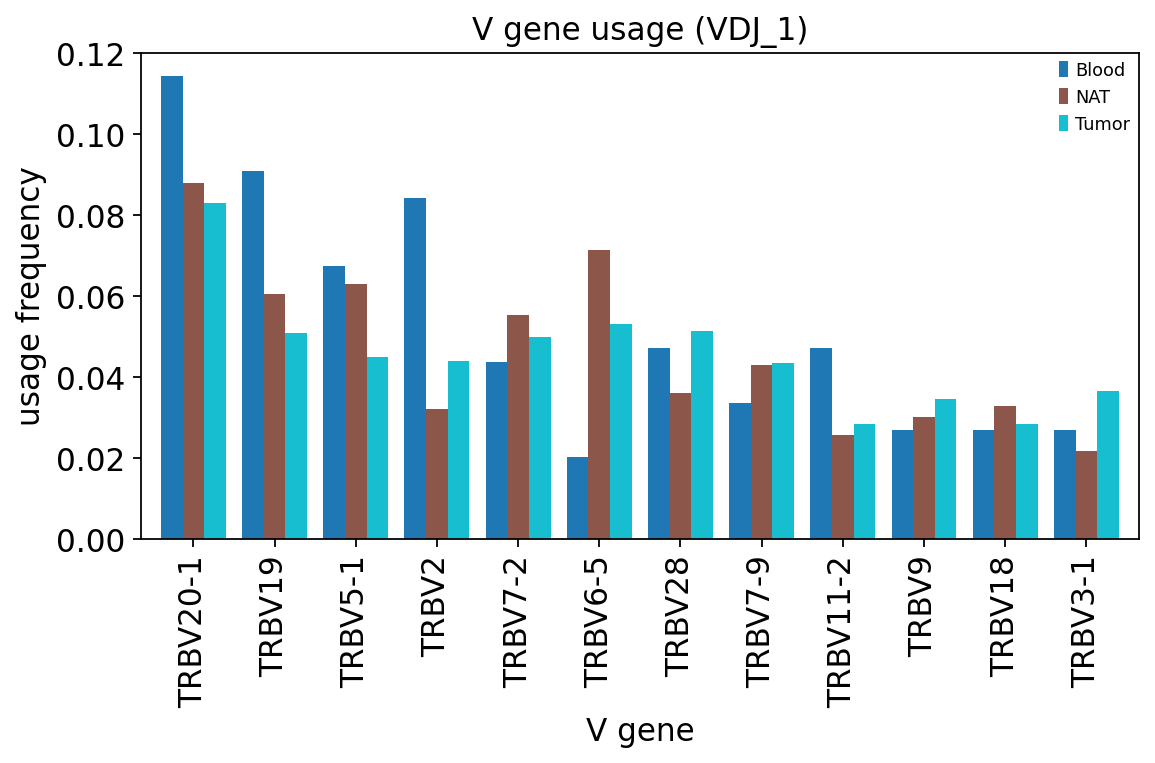

In [18]:
ov.airr.vdj_usage_plot(tcr, gene="v", chain="VDJ_1",
                       groupby="source", top=12)
plt.show()

The most-used **TRBV** segments are common, well-known genes
(e.g. TRBV20-1, TRBV28, TRBV9) and their frequencies are broadly **similar
across Tumor, NAT and Blood**. That is the expected result: V-gene usage is set
mostly by germline recombination biases, which are shared across a patient's
compartments. The tumour's clonal focusing seen in section 7 is driven by
**expansion of particular clones**, not by a wholesale shift in which V genes
are used — gene usage and clonal expansion are different axes of the
repertoire.

## 9. Repertoire meets transcriptome — the central question

Everything so far used only the TCR. Now we cross it with the GEX annotation in
`cell_type` to answer the question that motivates paired single-cell
immune-profiling: **which transcriptional states are clonally expanded?**

We tabulate, for every transcriptomic state, the fraction of its cells falling
in each clonal-expansion category. A state made mostly of singletons is *not*
proliferating; a state rich in large (`>= 4`) clones *is*.

In [19]:
ct_exp = pd.crosstab(tcr.obs["cell_type"], tcr.obs["clonal_expansion"],
                     normalize="index")
ct_exp = ct_exp.loc[ct_exp.index != "nan"]
ct_exp = ct_exp.sort_values(">= 4", ascending=False)
ct_exp.round(3)

clonal_expansion,1 (single),2,3,>= 4
cell_type,,,,
8.1-Teff,0.387,0.134,0.071,0.408
8.3b-Trm,0.469,0.144,0.067,0.321
8.3c-Trm,0.538,0.176,0.061,0.226
8.4-Chrom,0.652,0.087,0.043,0.217
8.2-Tem,0.611,0.152,0.065,0.172
8.3a-Trm,0.663,0.142,0.046,0.149
3.1-MT,0.656,0.138,0.064,0.142
8.5-Mitosis,0.661,0.102,0.102,0.136
4.1-Trm,0.794,0.131,0.025,0.050


The table is the punchline of the tutorial. Read the `>= 4` column —
the fraction of each state's cells sitting in a large, highly-expanded clone:

- the **CD8 effector / tissue-resident-memory** states top the list —
  `8.1-Teff`, `8.3b-Trm`, `8.3c-Trm`, `8.2-Tem`. These are the cytotoxic,
  antigen-experienced, exhaustion-leaning CD8 T cells, and they are by far the
  **most clonally expanded** compartment.
- the **CD4 naive-like and regulatory** states sit at the bottom —
  `4.3-TCF7` is almost entirely singletons, and the `4.x` states generally show
  little expansion.

This is precisely the Wu 2020 finding: clonal expansion is **not** spread
evenly across T-cell states — it is concentrated in the **effector / exhausted
CD8** compartment inside the tumour. Those are the tumour-reactive T cells that
recognised antigen, proliferated, and now dominate the tumour repertoire.

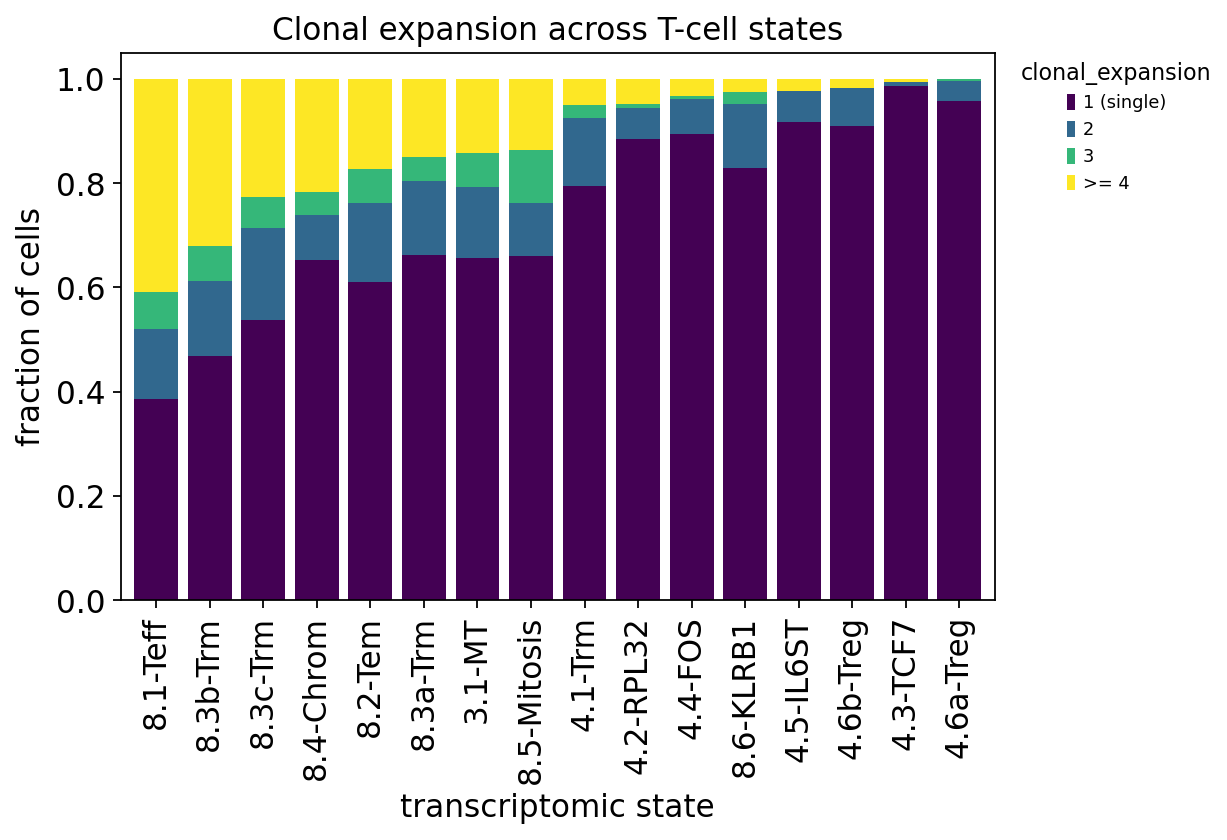

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ct_exp.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", width=0.82)
ax.set_ylabel("fraction of cells")
ax.set_xlabel("transcriptomic state")
ax.set_title("Clonal expansion across T-cell states")
ax.legend(title="clonal_expansion", bbox_to_anchor=(1.02, 1),
          loc="upper left", fontsize=8, frameon=False)
plt.show()

The stacked bars make it visual: the dark `1 (single)` block dominates the
naive/regulatory CD4 states on the right, while the bright `>= 4` band swells in
the CD8 effector/Trm states on the left. **Transcriptional state and clonal
behaviour are coupled** — and only paired single-cell data can show it.

We can also project the clonal signal straight onto the transcriptome UMAP: by
copying the per-cell `clone_id_size` from the TCR subset back onto the full
object, every cell's GEX position can be coloured by how expanded its clone
is.

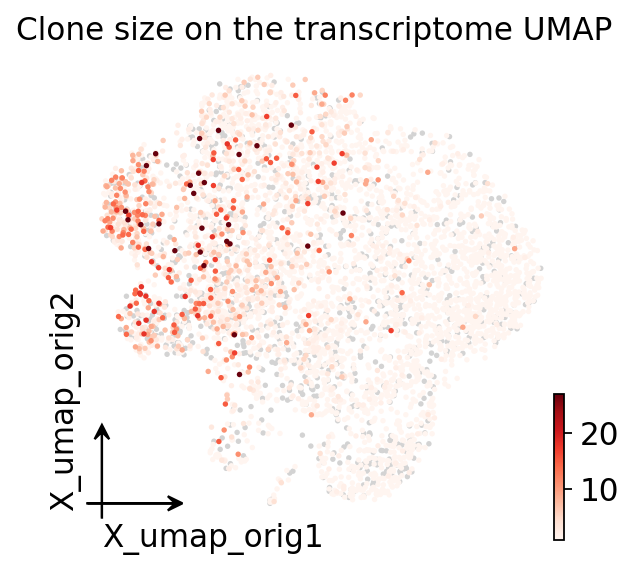

In [21]:
adata.obs["clone_size"] = np.nan
adata.obs.loc[tcr.obs_names, "clone_size"] = tcr.obs["clone_id_size"].values
ov.pl.embedding(adata, basis="X_umap_orig", color="clone_size",
                cmap="Reds", frameon="small",
                title="Clone size on the transcriptome UMAP", show=False)
plt.show()

The expanded (red) cells are not scattered at random — they pile up in the
**CD8 effector / Trm region** of the transcriptome, the same neighbourhood that
topped the table. The lineage barcode and the cell state tell one coherent
story.

## 10. Synthesis — the single-cell immune-repertoire recipe

The complete `ov.airr` single-cell pipeline:

```python
import omicverse as ov

# 1. load (or use read_10x_vdj / read_airr for your own data)
adata = ov.datasets.airr_singlecell()

# 2. bridge the receptor data into the per-cell ov.airr schema
adata = ov.airr.from_airr_array(adata)

# 3. chain QC — keep cells with a usable, plausible receptor
ov.airr.chain_qc(adata)
tcr = adata[adata.obs['chain_pairing'].isin(
    ['single pair', 'orphan VJ', 'orphan VDJ'])].copy()

# 4. define clonotypes (exact identity; or distance-based clusters)
ov.airr.define_clonotypes(tcr)

# 5. clonal expansion
ov.airr.clonal_expansion(tcr)

# 6. clonotype network
ov.airr.clonotype_network(tcr, min_cells=2)

# 7. diversity & overlap
ov.airr.alpha_diversity(tcr, groupby='source')
ov.airr.repertoire_overlap(tcr, groupby='patient')

# 8. V(D)J gene usage
ov.airr.vdj_usage(tcr, gene='v', chain='VDJ_1', groupby='source')

# 9. cross the TCR with the GEX cell_type — the central analysis
pd.crosstab(tcr.obs['cell_type'], tcr.obs['clonal_expansion'],
            normalize='index')
```

### What the analysis showed

1. **The receptor is a lineage barcode.** Cells sharing an identical CDR3 are
   clonal descendants — `define_clonotypes` reconstructs those families from
   sequence alone.
2. **QC before clonotypes.** Multichain doublets create fake clones; drop them
   with `chain_qc` *first*. ~4200 of 5000 cells carried a usable TCR.
3. **The tumour repertoire is clonally focused.** Clonal expansion is highest,
   and diversity lowest, in the tumour — local antigen drives proliferation.
4. **Clonotypes are patient-private.** Near-zero cross-patient overlap confirms
   both the biology and the clonotype definition.
5. **Expansion is state-specific.** Crossing TCR with transcriptome shows the
   expanded compartment is the **effector / exhausted CD8** T cells — the
   tumour-reactive cells. This coupling of clonal behaviour and cell state is
   only visible with paired single-cell data, and is the core result of
   Wu et al. 2020.

### See also

- `ov.airr` also covers **bulk repertoire** analysis (`repertoire_diversity`,
  `clonality`, `public_clonotypes`, …) and **B-cell / Ig** workflows
  (`clonal_clustering`, `mutation_analysis`, `lineage_trees`, …) — the same
  registered API, for the data types that are naturally tabular rather than
  AnnData-native.